# Lab 05: Iterative Solvers for Linear Systems

Direct methods (LU, Cholesky) solve $A\mathbf{x} = \mathbf{b}$ exactly in $O(n^3)$ operations.
For **large, sparse** systems — such as those arising from finite-difference or finite-element
discretization of PDEs — this cost becomes prohibitive. **Iterative methods** start from an
initial guess $\mathbf{x}^{(0)}$ and refine it step by step, often converging in far fewer
than $n$ steps when the matrix has exploitable structure.

## Learning Objectives

By the end of this session, you will be able to:
- Decompose $A$ into diagonal, lower, and upper parts ($D$, $L$, $U$)
- Derive and implement the **Jacobi** and **Gauss-Seidel** iteration schemes
- Monitor convergence with the relative approximate error criterion
- Apply the **diagonal dominance** test as a sufficient condition for convergence
- Compute the **spectral radius** $\rho(T)$ and interpret it as the convergence rate
- Accelerate convergence with **Successive Over-Relaxation (SOR)**
- Apply iterative methods to a 2D steady-state heat conduction problem

## Session Outline

| # | Topic | 
|---|-------| 
| 1 | Matrix Splitting and Fixed-Point Framework | 
| 2 | Jacobi Iteration | 
| 3 | Gauss-Seidel Method | 
| 4 | Convergence Analysis | 
| 5 | Successive Over-Relaxation (SOR) | 
| 6 | Application: 2D Steady Heat Conduction | 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

---
## 1. Matrix Splitting and the Fixed-Point Framework

### 1.1 Why Iterative Methods?

| Property | Direct (LU) | Iterative (Jacobi / GS / SOR) |
|----------|-------------|--------------------------------|
| Cost per solve | $O(n^3)$ — even for sparse $A$ | $O(\text{nnz})$ per iteration |
| Memory | $O(n^2)$ (fills in) | $O(\text{nnz})$ — preserves sparsity |
| Applies to | Any nonsingular $A$ | Converges only for certain $A$ |
| Best suited for | Dense, moderate $n$ | Large, sparse (FEM, FD grids) |

Here $\text{nnz}$ denotes the number of **nonzero** entries in $A$.
For a $100\times 100$ finite-difference grid, $n = 10{,}000$ and $\text{nnz} \approx 5n = 50{,}000$
— vastly fewer than the $n^2 = 10^8$ entries of the dense matrix.

### 1.2 Matrix Splitting: $A = D + L + U$

Every square matrix can be split into three parts:
$$A = D + L + U$$
where
- $D$ = **diagonal** part of $A$
- $L$ = **strictly lower triangular** part (zeros on diagonal and above)
- $U$ = **strictly upper triangular** part (zeros on diagonal and below)

$$A = \begin{bmatrix} a_{11} & a_{12} & a_{13} \\ a_{21} & a_{22} & a_{23} \\ a_{31} & a_{32} & a_{33} \end{bmatrix}
= \underbrace{\begin{bmatrix} a_{11} & & \\ & a_{22} & \\ & & a_{33} \end{bmatrix}}_{D}
+ \underbrace{\begin{bmatrix} 0 & & \\ a_{21} & 0 & \\ a_{31} & a_{32} & 0 \end{bmatrix}}_{L}
+ \underbrace{\begin{bmatrix} 0 & a_{12} & a_{13} \\ & 0 & a_{23} \\ & & 0 \end{bmatrix}}_{U}$$

### 1.3 General Fixed-Point Iteration

All classical iterative methods rewrite $A\mathbf{x} = \mathbf{b}$ as a fixed-point iteration:
$$\mathbf{x}^{(k+1)} = T\,\mathbf{x}^{(k)} + \mathbf{c}$$
where $T$ is the **iteration matrix** and $\mathbf{c}$ is a constant vector. Convergence
is guaranteed if and only if the **spectral radius** $\rho(T) = \max_i |\lambda_i(T)| < 1$.

In [ ]:
def split_DLU(A):
    """
    Split matrix A into diagonal D, strictly lower triangular L,
    and strictly upper triangular U such that A = D + L + U.

    Returns
    -------
    D, L, U : each (n, n) ndarray
    """
    A = np.array(A, dtype=float)
    n = A.shape[0]

    # --- COMPLETE ---
    D = np.diag(np.diag(A))                          # diagonal matrix (use np.diag twice)
    L =                                              # np.tril(A, -1)  # (strictly lower)
    U =                                              # np.triu(A,  1)  # (strictly upper)
    # --- COMPLETE ---

    return D, L, U


# Test with the example from the lecture notes
A_ex = np.array([[ 3.0, -0.1, -0.2],
                 [ 0.1,  7.0, -0.3],
                 [ 0.3, -0.2, 10.0]])
b_ex = np.array([7.85, -19.3, 71.4])   # true solution: x = [3, -2.5, 7]

D, L, U = split_DLU(A_ex)
print('D =\n', D)
print('L =\n', L)
print('U =\n', U)
print('\nSanity check  D + L + U - A =\n', D + L + U - A_ex)

D =
 [[ 3.  0.  0.]
 [ 0.  7.  0.]
 [ 0.  0. 10.]]
L =
 [[ 0.   0.   0. ]
 [ 0.1  0.   0. ]
 [ 0.3 -0.2  0. ]]
U =
 [[ 0.  -0.1 -0.2]
 [ 0.   0.  -0.3]
 [ 0.   0.   0. ]]

Sanity check  D + L + U - A =
 [[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


<!-- SOLUTION
L = np.tril(A, -1)
U = np.triu(A,  1)
-->

---
## 2. Jacobi Iteration

### 2.1 Derivation

Isolate $x_i$ from the $i$-th equation $\sum_j a_{ij} x_j = b_i$:

$$x_i^{(k+1)} = \frac{1}{a_{ii}}\left(b_i - \sum_{j \neq i} a_{ij}\, x_j^{(k)}\right),
\quad i = 0, 1, \ldots, n-1$$

All values on the right use the **previous** iterate $\mathbf{x}^{(k)}$, so the entire
new vector can be computed simultaneously (easy to parallelize).

**Matrix form** (splitting $A = D + (L + U)$, then $D\mathbf{x} = \mathbf{b} - (L+U)\mathbf{x}$):
$$\mathbf{x}^{(k+1)} = \underbrace{-D^{-1}(L+U)}_{T_J}\mathbf{x}^{(k)} + D^{-1}\mathbf{b}$$

### 2.2 Stopping Criterion

A common convergence test uses the **relative approximate error**:
$$\varepsilon_a = \frac{\|\mathbf{x}^{(k+1)} - \mathbf{x}^{(k)}\|_2}{\|\mathbf{x}^{(k+1)}\|_2} \times 100\%$$

Iteration stops when $\varepsilon_a < \varepsilon_s$ (a user-specified tolerance).

<!-- # x_new =                                       (b - R @ x) / d -->

In [ ]:
def jacobi(A, b, x0=None, tol=1e-6, max_iter=200):
    """
    Solve Ax = b using the Jacobi iteration.

    Parameters
    ----------
    A        : (n, n) array — coefficient matrix (must be diagonally dominant)
    b        : (n,)   array — right-hand side
    x0       : (n,)   array — initial guess (default: zeros)
    tol      : float        — relative error tolerance (stopping criterion)
    max_iter : int          — maximum number of iterations

    Returns
    -------
    x        : (n,) ndarray — approximate solution
    errors   : list of float — relative approximate error at each iteration
    """
    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float)
    n = len(b)

    x = np.zeros(n) if x0 is None else np.array(x0, dtype=float)
    errors = []

    d = np.diag(A)                  # diagonal entries a_{ii}
    R = A - np.diag(d)              # off-diagonal part  (L + U)

    for _ in range(max_iter):
        # --- COMPLETE ---
        x_new =                                       
        # --- COMPLETE ---

        # Relative approximate error
        if np.linalg.norm(x_new) > 0:
            ea = np.linalg.norm(x_new - x) / np.linalg.norm(x_new) * 100
        else:
            ea = np.inf
        errors.append(ea)

        x = x_new
        if ea < tol:
            break

    return x, errors

<!-- SOLUTION
x_new = (b - R @ x) / d
-->

In [5]:
# Test Jacobi on the lecture-notes example  (true solution: x = [3, -2.5, 7])
x_true = np.array([3.0, -2.5, 7.0])

x_jac, err_jac = jacobi(A_ex, b_ex, tol=1e-6)
x_ref          = np.linalg.solve(A_ex, b_ex)

print(f'Jacobi converged in {len(err_jac)} iterations')
print(f'Solution : {np.round(x_jac, 8)}')
print(f'Reference: {np.round(x_ref, 8)}')
print(f'Max error: {np.max(np.abs(x_jac - x_ref)):.2e}')

# Print iteration table
print(f'\n{"Iter":>5}  {"x1":>12}  {"x2":>12}  {"x3":>12}  {"ea (%)": >12}')
print('-' * 60)
x_k = np.zeros(3)
d_A = np.diag(A_ex)
R_A = A_ex - np.diag(d_A)
for k in range(min(8, len(err_jac))):
    x_k = (b_ex - R_A @ x_k) / d_A
    print(f'{k+1:>5}  {x_k[0]:>12.6f}  {x_k[1]:>12.6f}  {x_k[2]:>12.6f}  {err_jac[k]:>12.6f}')

Jacobi converged in 8 iterations
Solution : [ 3.  -2.5  7. ]
Reference: [ 3.  -2.5  7. ]
Max error: 2.24e-10

 Iter            x1            x2            x3        ea (%)
------------------------------------------------------------
    1      2.616667     -2.757143      7.140000    100.000000
    2      3.000762     -2.488524      7.006357      6.078749
    3      3.000806     -2.499738      7.000207      0.159563
    4      3.000022     -2.500003      6.999981      0.010697
    5      2.999999     -2.500001      6.999999      0.000375
    6      3.000000     -2.500000      7.000000      0.000023
    7      3.000000     -2.500000      7.000000      0.000001
    8      3.000000     -2.500000      7.000000      0.000000


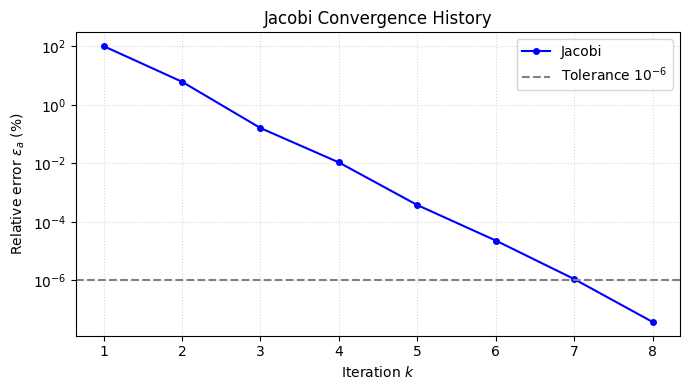

In [6]:
# Convergence history plot
plt.figure(figsize=(7, 4))
plt.semilogy(range(1, len(err_jac)+1), err_jac, 'b.-', ms=8, label='Jacobi')
plt.axhline(1e-6, color='gray', ls='--', label='Tolerance $10^{-6}$')
plt.xlabel('Iteration $k$')
plt.ylabel('Relative error $\\varepsilon_a$ (%)')
plt.title('Jacobi Convergence History')
plt.legend()
plt.grid(True, which='both', ls=':', alpha=0.5)
plt.tight_layout()
plt.show()

---
## 3. Gauss-Seidel Method

### 3.1 Key Improvement Over Jacobi

Jacobi computes all components of $\mathbf{x}^{(k+1)}$ using only **old** values.
Gauss-Seidel instead uses each **newly computed** component immediately:

$$x_i^{(k+1)} = \frac{1}{a_{ii}}\left(b_i
- \sum_{j=0}^{i-1} a_{ij}\, x_j^{(k+1)}
- \sum_{j=i+1}^{n-1} a_{ij}\, x_j^{(k)}\right)$$

The first sum uses **updated** values (already computed in this iteration),
while the second sum uses **old** values.

**Matrix form** (splitting $A = (D+L) + U$):
$$\mathbf{x}^{(k+1)} = \underbrace{-(D+L)^{-1}U}_{T_{GS}}\mathbf{x}^{(k)}
+ (D+L)^{-1}\mathbf{b}$$

| Feature | Jacobi | Gauss-Seidel |
|---------|--------|--------------|
| Values used | All old $\mathbf{x}^{(k)}$ | Mix: new for $j < i$, old for $j > i$ |
| Convergence rate | Slower | Typically $2\times$ faster |
| Parallelism | Easy (all components independent) | Sequential (each depends on previous) |
| Memory | Needs two copies of $\mathbf{x}$ | Can update in-place |

**Step-by-step for the 3×3 example** (1st iteration, $\mathbf{x}^{(0)} = \mathbf{0}$):

$$x_1^{(1)} = \frac{7.85 - (-0.1)(0) - (-0.2)(0)}{3} = 2.6167$$
$$x_2^{(1)} = \frac{-19.3 - (0.1)(\mathbf{2.6167}) - (-0.3)(0)}{7} = -2.7945 \quad \leftarrow\text{uses updated }x_1$$
$$x_3^{(1)} = \frac{71.4 - (0.3)(\mathbf{2.6167}) - (-0.2)(\mathbf{-2.7945})}{10} = 7.0056$$

<!-- sigma =                                  # A[i, :i] @ x[:i] + A[i, i+1:] @ x_old[i+1:]
x[i]  =                                  # (b[i] - sigma) / A[i, i] -->

In [ ]:
def gauss_seidel(A, b, x0=None, tol=1e-6, max_iter=200):
    """
    Solve Ax = b using the Gauss-Seidel iteration.

    Parameters
    ----------
    A, b, x0, tol, max_iter  — same as jacobi()

    Returns
    -------
    x      : (n,) ndarray — approximate solution
    errors : list of float — relative approximate error per iteration
    """
    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float)
    n = len(b)
    x = np.zeros(n) if x0 is None else np.array(x0, dtype=float)
    errors = []

    for _ in range(max_iter):
        x_old = x.copy()

        # Update each component using the most recently available values
        for i in range(n):
            # --- COMPLETE ---
            sigma =                                  
            x[i]  =                                  
            # --- COMPLETE ---

        # Relative approximate error
        if np.linalg.norm(x) > 0:
            ea = np.linalg.norm(x - x_old) / np.linalg.norm(x) * 100
        else:
            ea = np.inf
        errors.append(ea)

        if ea < tol:
            break

    return x, errors

<!-- SOLUTION
sigma = A[i, :i] @ x[:i] + A[i, i+1:] @ x_old[i+1:]
x[i]  = (b[i] - sigma) / A[i, i]
-->

Jacobi       converged in   8 iterations
Gauss-Seidel converged in   6 iterations
GS speedup (iterations): 1.3x

GS solution: [ 3.  -2.5  7. ]
True value : [ 3.  -2.5  7. ]


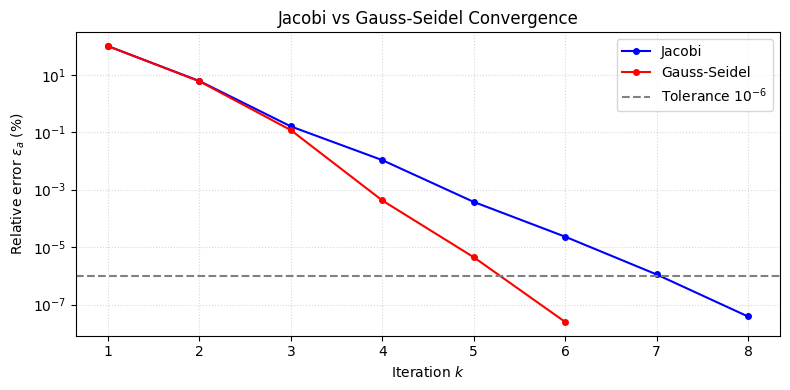

In [8]:
# Compare Jacobi vs Gauss-Seidel on the lecture-notes example
x_gs, err_gs = gauss_seidel(A_ex, b_ex, tol=1e-6)

print(f'Jacobi       converged in {len(err_jac):3d} iterations')
print(f'Gauss-Seidel converged in {len(err_gs):3d} iterations')
print(f'GS speedup (iterations): {len(err_jac)/len(err_gs):.1f}x')
print(f'\nGS solution: {np.round(x_gs, 8)}')
print(f'True value : {x_true}')

plt.figure(figsize=(8, 4))
plt.semilogy(range(1, len(err_jac)+1), err_jac, 'b.-', ms=8, label='Jacobi')
plt.semilogy(range(1, len(err_gs)+1),  err_gs,  'r.-', ms=8, label='Gauss-Seidel')
plt.axhline(1e-6, color='gray', ls='--', label='Tolerance $10^{-6}$')
plt.xlabel('Iteration $k$')
plt.ylabel('Relative error $\\varepsilon_a$ (%)')
plt.title('Jacobi vs Gauss-Seidel Convergence')
plt.legend()
plt.grid(True, which='both', ls=':', alpha=0.5)
plt.tight_layout()
plt.show()

### 3.2 Engineering Example: Steady-State Heat Network

Five nodes are connected in a thermal network. Nodes 1 and 5 are fixed at known temperatures.
At interior nodes 2, 3, 4, energy balance gives:

```
 T1=200°C ──[1]── 2 ──[1]── 3 ──[1]── 4 ──[1]── T5=50°C
                   |          |          |
                  [2]        [2]        [2]
                   |          |          |
                  GND        GND        GND
                 (0°C)      (0°C)      (0°C)
```

The conductance matrix (in W/°C) for interior nodes 2, 3, 4:

$$K = \begin{bmatrix} 4 & -1 & 0 \\ -1 & 4 & -1 \\ 0 & -1 & 4 \end{bmatrix},\quad
\mathbf{f} = \begin{bmatrix} 200 \\ 0 \\ 50 \end{bmatrix}$$

Note that $K$ is **symmetric and diagonally dominant** — ideal for Gauss-Seidel.

Node temperatures (°C):
  Node 2: T = 54.464286°C   (exact: 54.464286°C)
  Node 3: T = 17.857143°C   (exact: 17.857143°C)
  Node 4: T = 16.964286°C   (exact: 16.964286°C)

Converged in 13 iterations
Max error: 1.56e-10


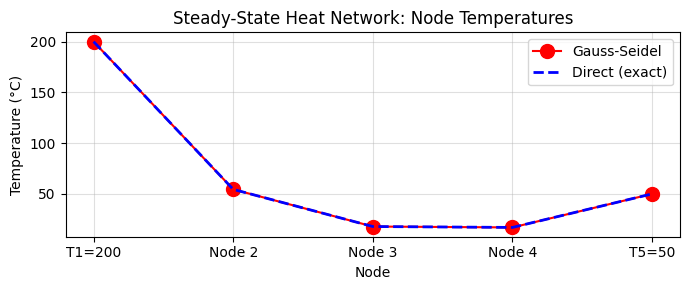

In [9]:
K_heat = np.array([[ 4.0, -1.0,  0.0],
                   [-1.0,  4.0, -1.0],
                   [ 0.0, -1.0,  4.0]])
f_heat = np.array([200.0, 0.0, 50.0])

# Solve with Gauss-Seidel
T_gs,  err_heat_gs  = gauss_seidel(K_heat, f_heat, tol=1e-8)
T_ref = np.linalg.solve(K_heat, f_heat)

print('Node temperatures (°C):')
for i, (t, t_ref) in enumerate(zip(T_gs, T_ref)):
    print(f'  Node {i+2}: T = {t:.6f}°C   (exact: {t_ref:.6f}°C)')
print(f'\nConverged in {len(err_heat_gs)} iterations')
print(f'Max error: {np.max(np.abs(T_gs - T_ref)):.2e}')

# Visualize the temperature distribution
x_nodes = np.array([0, 1, 2, 3, 4])
T_all   = np.array([200.0, T_gs[0], T_gs[1], T_gs[2], 50.0])
T_exact = np.array([200.0, T_ref[0], T_ref[1], T_ref[2], 50.0])

plt.figure(figsize=(7, 3))
plt.plot(x_nodes, T_all,   'ro-', ms=10, label='Gauss-Seidel')
plt.plot(x_nodes, T_exact, 'b--', lw=2,  label='Direct (exact)')
plt.xlabel('Node')
plt.ylabel('Temperature (°C)')
plt.title('Steady-State Heat Network: Node Temperatures')
plt.xticks(x_nodes, ['T1=200', 'Node 2', 'Node 3', 'Node 4', 'T5=50'])
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
## 4. Convergence Analysis

### 4.1 Diagonal Dominance (Sufficient Condition)

Matrix $A$ is **strictly diagonally dominant** if, for every row $i$:
$$|a_{ii}| > \sum_{j \neq i} |a_{ij}|$$

**Theorem:** If $A$ is strictly diagonally dominant, then both Jacobi and Gauss-Seidel
converge for any initial guess $\mathbf{x}^{(0)}$.

This is only a **sufficient** condition — iterative methods may still converge for
matrices that are not strictly diagonally dominant.

**Check for a 3×3 matrix:**
$$A = \begin{bmatrix} 3 & -0.1 & -0.2 \\ 0.1 & 7 & -0.3 \\ 0.3 & -0.2 & 10 \end{bmatrix}$$
- Row 0: $|3| > |-0.1| + |-0.2| = 0.3$ ✓
- Row 1: $|7| > |0.1| + |-0.3| = 0.4$ ✓
- Row 2: $|10| > |0.3| + |-0.2| = 0.5$ ✓

In [10]:
def is_diag_dominant(A, strict=True):
    """
    Check whether A is (strictly) diagonally dominant.

    Returns
    -------
    dominant : bool
    margins  : (n,) array — |a_ii| - sum_{j!=i}|a_ij| for each row
                             Positive margin means the row is dominant.
    """
    A = np.array(A, dtype=float)

    # --- COMPLETE ---
    diag_abs = np.abs(np.diag(A))                    # |a_ii|
    offdiag_sum =  np.sum(np.abs(A), axis=1) - diag_abs                                   # row sums of |A| minus the diagonal
                                                     # hint: np.sum(np.abs(A), axis=1) - diag_abs
    margins =                                         diag_abs - offdiag_sum
    # --- COMPLETE ---

    if strict:
        dominant = bool(np.all(margins > 0))
    else:
        dominant = bool(np.all(margins >= 0))
    return dominant, margins


# Test on well-conditioned and poorly-conditioned matrices
A_good = np.array([[ 4.0, -1.0,  0.5],
                   [ 0.2,  5.0, -1.0],
                   [-0.5,  0.3,  6.0]])

A_bad  = np.array([[ 1.0,  2.0, -3.0],
                   [ 1.5,  2.0,  0.5],
                   [-1.0,  1.0,  1.0]])

dom_good, mar_good = is_diag_dominant(A_good)
dom_bad,  mar_bad  = is_diag_dominant(A_bad)

print('A_good — strictly diagonally dominant:', dom_good)
print('  Row margins:', np.round(mar_good, 4))

print('\nA_bad  — strictly diagonally dominant:', dom_bad)
print('  Row margins:', np.round(mar_bad, 4))

# Check our lecture-notes example
dom_ex, mar_ex = is_diag_dominant(A_ex)
print(f'\nA_ex   — strictly diagonally dominant: {dom_ex},  margins: {np.round(mar_ex, 4)}')

A_good — strictly diagonally dominant: True
  Row margins: [2.5 3.8 5.2]

A_bad  — strictly diagonally dominant: False
  Row margins: [-4.  0. -1.]

A_ex   — strictly diagonally dominant: True,  margins: [2.7 6.6 9.5]


<!-- SOLUTION
offdiag_sum = np.sum(np.abs(A), axis=1) - diag_abs
margins     = diag_abs - offdiag_sum
-->

### 4.2 Spectral Radius (Necessary and Sufficient Condition)

The **spectral radius** of the iteration matrix $T$ is:
$$\rho(T) = \max_i |\lambda_i(T)|$$
where $\lambda_i(T)$ are the eigenvalues of $T$.

**Theorem:** The iteration $\mathbf{x}^{(k+1)} = T\mathbf{x}^{(k)} + \mathbf{c}$ converges
for any $\mathbf{x}^{(0)}$ **if and only if** $\rho(T) < 1$.

Furthermore, the **convergence rate** is approximately $-\log_{10}(\rho(T))$ digits per iteration:
- $\rho(T) = 0.1 \Rightarrow$ one decimal digit gained per iteration
- $\rho(T) = 0.9 \Rightarrow$ very slow convergence
- $\rho(T) = 1.0 \Rightarrow$ no convergence
- $\rho(T) > 1.0 \Rightarrow$ divergence

**Iteration matrices:**
$$T_J = -D^{-1}(L + U), \qquad T_{GS} = -(D+L)^{-1}U$$

- $\mathbf{x}^{(k+1)} = T\mathbf{x}^{(k)} + \mathbf{c}$ 
- $\mathbf{x}^{*} = T\mathbf{x}^{*} + \mathbf{c}$  
- $\mathbf{x}^{(k+1)} - \mathbf{x}^{*} = \mathbf{e}^{(k+1)} = T\mathbf{e}^{(k)} $
- we want $\mathbf{e}^{(k)} \rightarrow 0$


In [11]:
def iteration_matrices(A):
    """Compute Jacobi and Gauss-Seidel iteration matrices for matrix A."""
    A = np.array(A, dtype=float)
    D, L, U = split_DLU(A)
    D_inv = np.diag(1.0 / np.diag(D))

    T_J  = -D_inv @ (L + U)                     # Jacobi iteration matrix
    T_GS = -np.linalg.solve(D + L, U)           # Gauss-Seidel iteration matrix

    return T_J, T_GS


def spectral_radius(T):
    """Compute the spectral radius max|eigenvalue| of matrix T."""
    eigvals = np.linalg.eigvals(T)
    return np.max(np.abs(eigvals))


# Analyze our examples
for name, A in [('A_ex (lecture)', A_ex),
                ('K_heat (heat network)', K_heat),
                ('A_good', A_good),
                ('A_bad', A_bad)]:
    T_J, T_GS = iteration_matrices(A)
    rho_J  = spectral_radius(T_J)
    rho_GS = spectral_radius(T_GS)
    conv_J  = 'converges' if rho_J  < 1 else 'DIVERGES'
    conv_GS = 'converges' if rho_GS < 1 else 'DIVERGES'
    print(f'{name}:')
    print(f'  rho(T_J)  = {rho_J:.4f}  -> Jacobi {conv_J}')
    print(f'  rho(T_GS) = {rho_GS:.4f}  -> Gauss-Seidel {conv_GS}')
    if rho_J < 1 and rho_GS < 1:
        print(f'  GS speedup factor: {np.log(rho_J)/np.log(rho_GS):.2f}x per iteration')
    print()

A_ex (lecture):
  rho(T_J)  = 0.0482  -> Jacobi converges
  rho(T_GS) = 0.0065  -> Gauss-Seidel converges
  GS speedup factor: 0.60x per iteration

K_heat (heat network):
  rho(T_J)  = 0.3536  -> Jacobi converges
  rho(T_GS) = 0.1250  -> Gauss-Seidel converges
  GS speedup factor: 0.50x per iteration

A_good:
  rho(T_J)  = 0.2000  -> Jacobi converges
  rho(T_GS) = 0.0817  -> Gauss-Seidel converges
  GS speedup factor: 0.64x per iteration

A_bad:
  rho(T_J)  = 2.4256  -> Jacobi DIVERGES
  rho(T_GS) = 7.0707  -> Gauss-Seidel DIVERGES



In [12]:
# Demonstrate divergence: what happens when rho(T) > 1?
# Swap rows of A_bad to make it non-diagonally-dominant
A_div = np.array([[ 1.0,  2.0, -3.0],
                  [ 1.5,  2.0,  0.5],
                  [-1.0,  1.0,  1.0]])

T_J_div, _ = iteration_matrices(A_div)
rho_div = spectral_radius(T_J_div)
print(f'A_div: rho(T_J) = {rho_div:.4f}  (> 1 => diverges!)')

x_ref_div = np.linalg.solve(A_div, np.ones(3))
print(f'True solution: {x_ref_div}')

# Run Jacobi for a few iterations and watch it diverge
x_k = np.zeros(3)
d_div = np.diag(A_div)
R_div = A_div - np.diag(d_div)
b_div = np.ones(3)

print(f'\n{"Iter":>5}  {"x1":>12}  {"x2":>12}  {"x3":>12}  {"||x||":>12}')
print('-' * 60)
for k in range(10):
    x_k = (b_div - R_div @ x_k) / d_div
    print(f'{k+1:>5}  {x_k[0]:>12.4f}  {x_k[1]:>12.4f}  {x_k[2]:>12.4f}  {np.linalg.norm(x_k):>12.4f}')

A_div: rho(T_J) = 2.4256  (> 1 => diverges!)
True solution: [-0.26923077  0.69230769  0.03846154]

 Iter            x1            x2            x3         ||x||
------------------------------------------------------------
    1        1.0000        0.5000        1.0000        1.5000
    2        3.0000       -0.5000        1.5000        3.3912
    3        6.5000       -2.1250        4.5000        8.1863
    4       18.7500       -5.5000        9.6250       21.7819
    5       40.8750      -15.9688       25.2500       50.6293
    6      108.6875      -36.4688       57.8438      128.4089
    7      247.4688      -95.4766      146.1562      302.8501
    8      630.4219     -221.6406      343.9453      751.5682
    9     1476.1172     -558.3027      853.0625     1793.9731
   10     3676.7930    -1319.8535     2035.4199     4404.9693


---
## 5. Successive Over-Relaxation (SOR)

### 5.1 Motivation

Gauss-Seidel takes a step from $x_i^{(k)}$ to a new value $\tilde{x}_i^{(k+1)}$.
SOR **overshoots** this update by a factor $\omega > 1$ to accelerate convergence:

$$x_i^{(k+1)} = (1 - \omega)\,x_i^{(k)}
+ \frac{\omega}{a_{ii}}\left(b_i
- \sum_{j < i} a_{ij}\, x_j^{(k+1)}
- \sum_{j > i} a_{ij}\, x_j^{(k)}\right)$$

| $\omega$ | Name | Effect |
|----------|------|--------|
| $\omega = 1$ | Gauss-Seidel | No acceleration |
| $1 < \omega < 2$ | Over-relaxation (SOR) | Faster convergence |
| $0 < \omega < 1$ | Under-relaxation | Slower; useful to stabilize divergent cases |
| $\omega \geq 2$ | — | Diverges |

**Optimal $\omega$** minimizes $\rho(T_{SOR}(\omega))$. For the tridiagonal model problem
(5-point Laplace stencil on an $n\times n$ grid):
$$\omega_{\text{opt}} = \frac{2}{1 + \sqrt{1 - \rho(T_J)^2}}$$

In [13]:
def sor(A, b, omega=1.0, x0=None, tol=1e-6, max_iter=500):
    """
    Solve Ax = b using Successive Over-Relaxation (SOR).

    Parameters
    ----------
    A, b, x0, tol, max_iter — same as gauss_seidel()
    omega  : float — relaxation parameter (0 < omega < 2)

    Returns
    -------
    x      : (n,) ndarray
    errors : list of float
    """
    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float)
    n = len(b)
    x = np.zeros(n) if x0 is None else np.array(x0, dtype=float)
    errors = []

    for _ in range(max_iter):
        x_old = x.copy()

        for i in range(n):
            # Gauss-Seidel update (x_gs_i)
            sigma  = A[i, :i] @ x[:i] + A[i, i+1:] @ x_old[i+1:]
            x_gs_i = (b[i] - sigma) / A[i, i]

            # --- COMPLETE: apply SOR blending ---
            x[i] =                                    (1 - omega) * x_old[i] + omega * x_gs_i
            # --- COMPLETE ---

        if np.linalg.norm(x) > 0:
            ea = np.linalg.norm(x - x_old) / np.linalg.norm(x) * 100
        else:
            ea = np.inf
        errors.append(ea)

        if ea < tol:
            break

    return x, errors

<!-- SOLUTION
x[i] = (1 - omega) * x_old[i] + omega * x_gs_i
-->

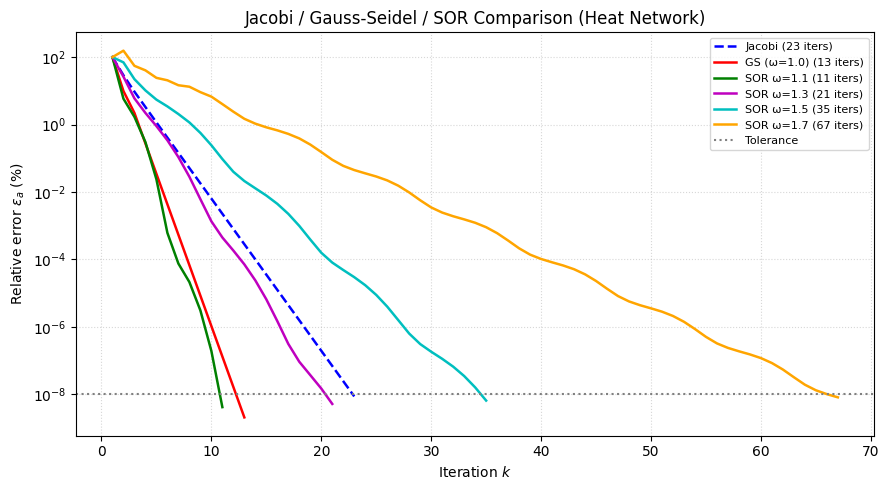


Method            Iterations
----------------------------
Jacobi                    23
GS (ω=1.0)                13
SOR ω=1.1                 11
SOR ω=1.3                 21
SOR ω=1.5                 35
SOR ω=1.7                 67


In [14]:
# Compare Jacobi, GS, and SOR (ω = 1.1, 1.3, 1.5) on the heat network
results = {}
x_jac_h, err_jac_h = jacobi(K_heat, f_heat, tol=1e-8)
results['Jacobi'] = err_jac_h
results['GS (ω=1.0)'] = err_heat_gs

for w in [1.1, 1.3, 1.5, 1.7]:
    _, err = sor(K_heat, f_heat, omega=w, tol=1e-8)
    results[f'SOR ω={w}'] = err

plt.figure(figsize=(9, 5))
styles = ['b--', 'r-', 'g-', 'm-', 'c-', 'orange']
for (label, errs), style in zip(results.items(), styles):
    plt.semilogy(range(1, len(errs)+1), errs, style, lw=1.8, label=f'{label} ({len(errs)} iters)')
plt.axhline(1e-8, color='gray', ls=':', label='Tolerance')
plt.xlabel('Iteration $k$')
plt.ylabel('Relative error $\\varepsilon_a$ (%)')
plt.title('Jacobi / Gauss-Seidel / SOR Comparison (Heat Network)')
plt.legend(fontsize=8)
plt.grid(True, which='both', ls=':', alpha=0.5)
plt.tight_layout()
plt.show()

print(f'\n{"Method":<14}  {"Iterations":>12}')
print('-' * 28)
for label, errs in results.items():
    print(f'{label:<14}  {len(errs):>12}')

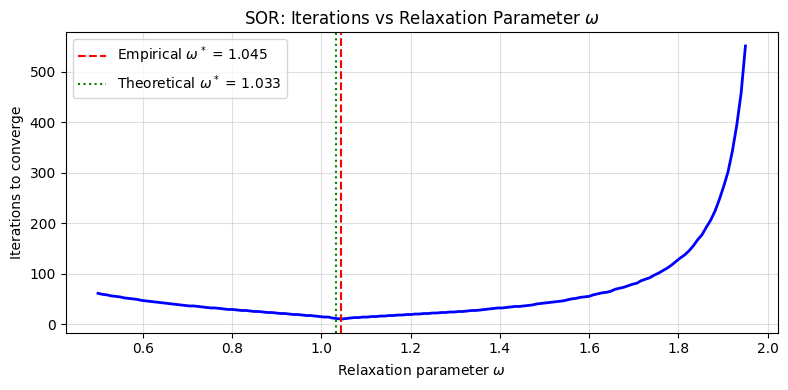

Empirical optimal omega : 1.045  (10 iters)
Theoretical optimal omega: 1.033
GS iterations            : 13
Best SOR iterations      : 10
SOR speedup over GS      : 1.3x


In [15]:
# Find optimal omega empirically for the K_heat system
omegas = np.linspace(0.5, 1.95, 150)
iters_needed = []

for w in omegas:
    _, err = sor(K_heat, f_heat, omega=w, tol=1e-10, max_iter=1000)
    iters_needed.append(len(err))

best_idx   = np.argmin(iters_needed)
omega_best = omegas[best_idx]

# Theoretical optimal for this tridiagonal system
rho_J_heat = spectral_radius(iteration_matrices(K_heat)[0])
omega_theory = 2.0 / (1.0 + np.sqrt(1.0 - rho_J_heat**2))

plt.figure(figsize=(8, 4))
plt.plot(omegas, iters_needed, 'b-', lw=2)
plt.axvline(omega_best,   color='r', ls='--', label=f'Empirical $\\omega^*$ = {omega_best:.3f}')
plt.axvline(omega_theory, color='g', ls=':',  label=f'Theoretical $\\omega^*$ = {omega_theory:.3f}')
plt.xlabel('Relaxation parameter $\\omega$')
plt.ylabel('Iterations to converge')
plt.title('SOR: Iterations vs Relaxation Parameter $\\omega$')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print(f'Empirical optimal omega : {omega_best:.3f}  ({iters_needed[best_idx]} iters)')
print(f'Theoretical optimal omega: {omega_theory:.3f}')
print(f'GS iterations            : {len(err_heat_gs)}')
print(f'Best SOR iterations      : {iters_needed[best_idx]}')
print(f'SOR speedup over GS      : {len(err_heat_gs)/iters_needed[best_idx]:.1f}x')

---
## 6. Application: 2D Steady-State Heat Conduction

### 6.1 Problem Setup

Consider a square plate $[0,1]\times[0,1]$ with boundary conditions:
- Bottom ($y=0$): $T = 0\,^\circ\text{C}$
- Top ($y=1$): $T = 100\,^\circ\text{C}$  
- Left ($x=0$) and Right ($x=1$): $T = 0\,^\circ\text{C}$

The steady-state temperature satisfies the 2D Laplace equation:
$$\frac{\partial^2 T}{\partial x^2} + \frac{\partial^2 T}{\partial y^2} = 0$$

**Finite-difference discretization** on an $(n+2)\times(n+2)$ grid (step $h = 1/(n+1)$):
$$T_{i-1,j} + T_{i+1,j} + T_{i,j-1} + T_{i,j+1} - 4T_{i,j} = 0$$

This **5-point stencil** produces a large, sparse, symmetric system with $n^2$ unknowns
and only $5n^2$ nonzeros — the perfect candidate for iterative solvers.

### 6.2 Direct Gauss-Seidel on the Grid (No Assembly)

Rather than assembling the full sparse matrix (which would be $n^2 \times n^2$),
we sweep directly over the grid using the stencil:

In [16]:
def solve_laplace_2d(n, T_top=100.0, T_bot=0.0, T_left=0.0, T_right=0.0,
                     method='gs', omega=1.0, tol=1e-6, max_iter=5000):
    """
    Solve the 2D Laplace equation on an (n+2) x (n+2) grid using
    a point iterative method (Gauss-Seidel or SOR).

    Interior nodes: indices 1..n, 1..n
    Returns T : (n+2, n+2) temperature array, iters : iteration count
    """
    T = np.zeros((n + 2, n + 2))

    # Boundary conditions
    T[0,  :]  = T_bot
    T[-1, :]  = T_top
    T[:, 0]   = T_left
    T[:, -1]  = T_right

    iters = 0
    for it in range(max_iter):
        T_old = T.copy()

        # Sweep interior nodes
        for i in range(1, n + 1):          # row index
            for j in range(1, n + 1):      # column index
                # Gauss-Seidel update for the 5-point stencil
                T_gs = 0.25 * (T[i-1, j] + T[i+1, j] + T[i, j-1] + T[i, j+1])

                if method == 'sor':
                    # --- COMPLETE: apply SOR blending ---
                    T[i, j] =                         (1 - omega) * T[i, j] + omega * T_gs
                    # --- COMPLETE ---
                else:
                    T[i, j] = T_gs

        iters += 1

        # Convergence check on interior nodes
        diff = np.max(np.abs(T[1:-1, 1:-1] - T_old[1:-1, 1:-1]))
        if diff < tol:
            break

    return T, iters

<!-- SOLUTION
T[i, j] = (1 - omega) * T[i, j] + omega * T_gs
-->

2D Laplace (n=30, 900 unknowns):
  Gauss-Seidel : 1267 iterations
  SOR (ω=1.7)  :  243 iterations
  SOR speedup  : 5.2x
  Max |GS - SOR|: 8.22e-05


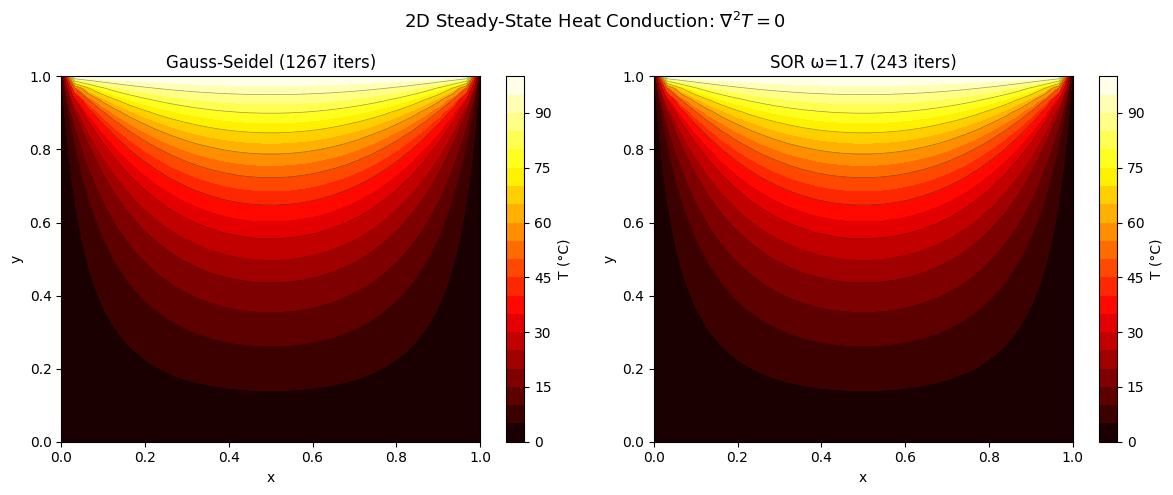

In [17]:
# Solve and visualize for n = 30
n_grid = 30

T_gs_2d,  it_gs  = solve_laplace_2d(n_grid, method='gs',  tol=1e-6)
T_sor_2d, it_sor = solve_laplace_2d(n_grid, method='sor', omega=1.7, tol=1e-6)

print(f'2D Laplace (n={n_grid}, {n_grid**2} unknowns):')
print(f'  Gauss-Seidel : {it_gs:4d} iterations')
print(f'  SOR (ω=1.7)  : {it_sor:4d} iterations')
print(f'  SOR speedup  : {it_gs / it_sor:.1f}x')
print(f'  Max |GS - SOR|: {np.max(np.abs(T_gs_2d - T_sor_2d)):.2e}')

# Plot
x = y = np.linspace(0, 1, n_grid + 2)
X, Y = np.meshgrid(x, y)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (T_plot, title) in zip(axes,
    [(T_gs_2d,  f'Gauss-Seidel ({it_gs} iters)'),
     (T_sor_2d, f'SOR ω=1.7 ({it_sor} iters)')]):
    cf = ax.contourf(X, Y, T_plot, 20, cmap='hot')
    fig.colorbar(cf, ax=ax, label='T (°C)')
    ax.contour(X, Y, T_plot, 10, colors='k', linewidths=0.5, alpha=0.4)
    ax.set(title=title, xlabel='x', ylabel='y')

plt.suptitle('2D Steady-State Heat Conduction: $\\nabla^2 T = 0$', fontsize=13)
plt.tight_layout()
plt.show()

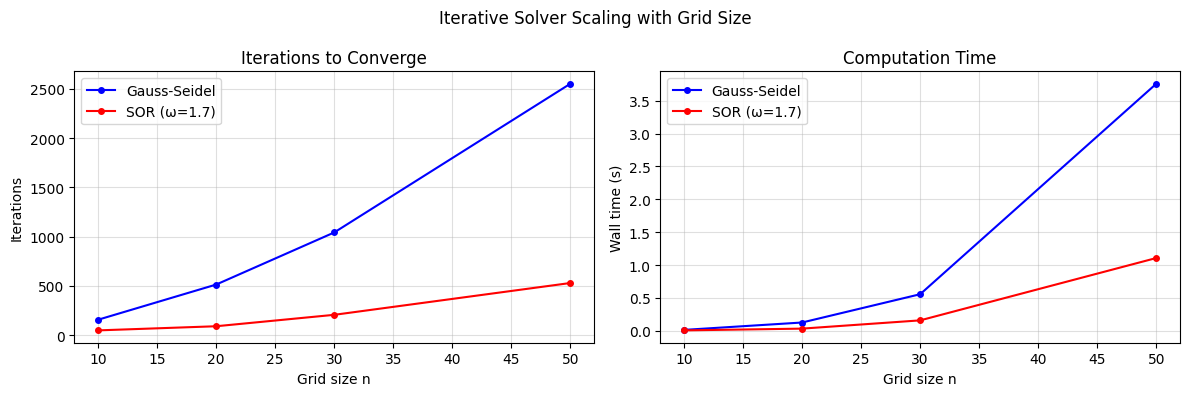


   n    unknowns    GS iters   SOR iters   SOR speedup
------------------------------------------------------
  10         100         157          49           3.2x
  20         400         514          91           5.6x
  30         900        1043         207           5.0x
  50        2500        2553         530           4.8x


In [18]:
# Scaling: iterations and time vs grid size
grid_sizes = [10, 20, 30, 50]
it_gs_list, it_sor_list = [], []
t_gs_list,  t_sor_list  = [], []

for n in grid_sizes:
    t0 = time.perf_counter()
    _, it_g = solve_laplace_2d(n, method='gs',  tol=1e-5)
    t_gs_list.append(time.perf_counter() - t0)
    it_gs_list.append(it_g)

    t0 = time.perf_counter()
    _, it_s = solve_laplace_2d(n, method='sor', omega=1.7, tol=1e-5)
    t_sor_list.append(time.perf_counter() - t0)
    it_sor_list.append(it_s)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(grid_sizes, it_gs_list,  'b.-', ms=8, label='Gauss-Seidel')
ax1.plot(grid_sizes, it_sor_list, 'r.-', ms=8, label='SOR (ω=1.7)')
ax1.set(xlabel='Grid size n', ylabel='Iterations', title='Iterations to Converge')
ax1.legend(); ax1.grid(True, alpha=0.4)

ax2.plot(grid_sizes, t_gs_list,  'b.-', ms=8, label='Gauss-Seidel')
ax2.plot(grid_sizes, t_sor_list, 'r.-', ms=8, label='SOR (ω=1.7)')
ax2.set(xlabel='Grid size n', ylabel='Wall time (s)', title='Computation Time')
ax2.legend(); ax2.grid(True, alpha=0.4)

plt.suptitle('Iterative Solver Scaling with Grid Size', fontsize=12)
plt.tight_layout()
plt.show()

print(f'\n{"n":>4}  {"unknowns":>10}  {"GS iters":>10}  {"SOR iters":>10}  {"SOR speedup":>12}')
print('-' * 54)
for n, ig, is_ in zip(grid_sizes, it_gs_list, it_sor_list):
    print(f'{n:>4}  {n**2:>10}  {ig:>10}  {is_:>10}  {ig/is_:>12.1f}x')

---
## Summary

### Method Comparison

| Method | Iteration Formula | Convergence | Best For |
|--------|-------------------|-------------|----------|
| **Jacobi** | $x_i^{(k+1)} = (b_i - \sum_{j\neq i}a_{ij}x_j^{(k)})/a_{ii}$ | $\rho(T_J) < 1$ | Parallel architectures |
| **Gauss-Seidel** | Uses updated $x_j^{(k+1)}$ for $j < i$ | $\rho(T_{GS}) < 1$ | Serial; ~2× faster than Jacobi |
| **SOR** | GS blended with old value, weight $\omega$ | $0 < \omega < 2$ | Grid problems; optimal $\omega$ gives big speedup |

Gauss–Seidel achieves faster convergence than Jacobi due to its use of updated iterates within each sweep, which effectively introduces a stronger lower-triangular correction, reducing the spectral radius of the iteration matrix.

### Key Formulas

| Concept | Formula |
|---------|--------|
| **Splitting** | $A = D + L + U$ (diagonal, strictly lower, strictly upper) |
| **Jacobi matrix** | $T_J = -D^{-1}(L+U)$ |
| **GS matrix** | $T_{GS} = -(D+L)^{-1}U$ |
| **Spectral radius** | $\rho(T) = \max_i\|\lambda_i(T)\|$ — must be $< 1$ for convergence |
| **Diagonal dominance** | $ \|a_{ii}\| > \sum_{j\neq i}\|a_{ij}\| $ — sufficient for convergence |
| **Relative error** | $\varepsilon_a = \|\mathbf{x}^{(k+1)}-\mathbf{x}^{(k)}\|/\|\mathbf{x}^{(k+1)}\|\times 100\%$ |
| **Optimal SOR** (tridiagonal) | $\omega^* = 2/(1+\sqrt{1-\rho_J^2})$ |

### When to Choose Iterative vs Direct

| Scenario | Recommended Method |
|----------|-------------------|
| $n < 1{,}000$, any structure | Direct (LU / Cholesky) |
| $n \gg 10{,}000$, sparse, diagonally dominant | Gauss-Seidel or SOR |
| SPD matrix, large and sparse | Conjugate Gradient (beyond this lab) |
| Non-diagonally dominant | Check $\rho(T)$ before committing to iterative |
| Multiple right-hand sides, fixed $A$ | Direct with `lu_factor` / `lu_solve` |